# Step 1: 데이터 수집 및 정리

In [23]:
import pandas as pd

# 1. 데이터 불러오기
train = pd.read_csv("train.csv", parse_dates=["date"])
test = pd.read_csv("test.csv", parse_dates=["date"])
stores = pd.read_csv("stores.csv")
transactions = pd.read_csv("transactions.csv", parse_dates=["date"])
oil = pd.read_csv("oil.csv", parse_dates=["date"])
holidays = pd.read_csv("holidays_events.csv", parse_dates=["date"])

# 2. store 정보 병합
train = train.merge(stores, on="store_nbr", how="left")
test = test.merge(stores, on="store_nbr", how="left")

# 3. 거래수 정보 병합
train = train.merge(transactions, on=["date", "store_nbr"], how="left")
test = test.merge(transactions, on=["date", "store_nbr"], how="left")

# 4. 유가 정보 병합
train = train.merge(oil, on="date", how="left")
test = test.merge(oil, on="date", how="left")

# 5. 공휴일 정보 병합 (중복 제거 필수)
holidays_dedup = holidays.drop_duplicates(subset=["date"])
train = train.merge(holidays_dedup, on="date", how="left")
test = test.merge(holidays_dedup, on="date", how="left")


In [24]:
train

,id,date,store_nbr,family,sales,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,0,2013-01-01,1,AUTOMOTIVE,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
1,1,2013-01-01,1,BABY CARE,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
2,2,2013-01-01,1,BEAUTY,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
3,3,2013-01-01,1,BEVERAGES,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
4,4,2013-01-01,1,BOOKS,0.000,0,Quito,Pichincha,D,13,NaN,NaN,Holiday,National,Ecuador,Primer dia del ano,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3000883,3000883,2017-08-15,9,POULTRY,438.133,0,Quito,Pichincha,B,6,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000884,3000884,2017-08-15,9,PREPARED FOODS,154.553,1,Quito,Pichincha,B,6,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000885,3000885,2017-08-15,9,PRODUCE,2419.729,148,Quito,Pichincha,B,6,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False
3000886,3000886,2017-08-15,9,SCHOOL AND OFFICE SUPPLIES,121.000,8,Quito,Pichincha,B,6,2155.0,47.57,Holiday,Local,Riobamba,Fundacion de Riobamba,False


In [25]:
test

,id,date,store_nbr,family,onpromotion,city,state,type_x,cluster,transactions,dcoilwtico,type_y,locale,locale_name,description,transferred
0,3000888,2017-08-16,1,AUTOMOTIVE,0,Quito,Pichincha,D,13,NaN,46.80,NaN,NaN,NaN,NaN,NaN
1,3000889,2017-08-16,1,BABY CARE,0,Quito,Pichincha,D,13,NaN,46.80,NaN,NaN,NaN,NaN,NaN
2,3000890,2017-08-16,1,BEAUTY,2,Quito,Pichincha,D,13,NaN,46.80,NaN,NaN,NaN,NaN,NaN
3,3000891,2017-08-16,1,BEVERAGES,20,Quito,Pichincha,D,13,NaN,46.80,NaN,NaN,NaN,NaN,NaN
4,3000892,2017-08-16,1,BOOKS,0,Quito,Pichincha,D,13,NaN,46.80,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
28507,3029395,2017-08-31,9,POULTRY,1,Quito,Pichincha,B,6,NaN,47.26,NaN,NaN,NaN,NaN,NaN
28508,3029396,2017-08-31,9,PREPARED FOODS,0,Quito,Pichincha,B,6,NaN,47.26,NaN,NaN,NaN,NaN,NaN
28509,3029397,2017-08-31,9,PRODUCE,1,Quito,Pichincha,B,6,NaN,47.26,NaN,NaN,NaN,NaN,NaN
28510,3029398,2017-08-31,9,SCHOOL AND OFFICE SUPPLIES,9,Quito,Pichincha,B,6,NaN,47.26,NaN,NaN,NaN,NaN,NaN


---

# step 2: EDA 및 시각화

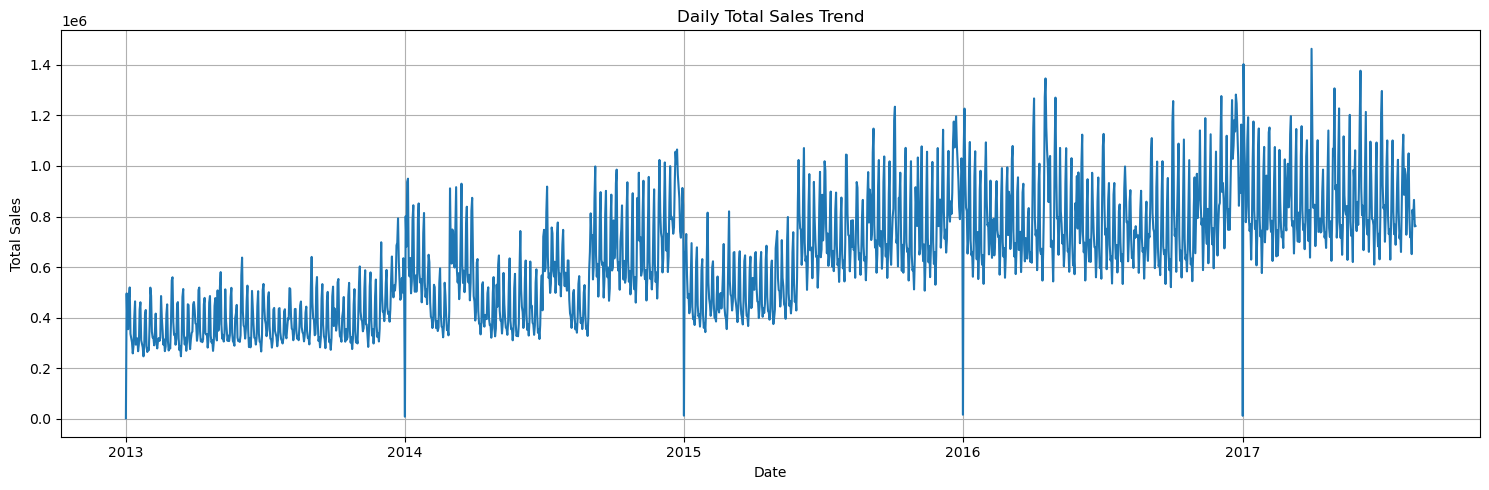

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# 날짜별 전체 매출 합계 산출
daily_sales = train.groupby("date")["sales"].sum()

# 전체 일자별 판매 추세 시각화
plt.figure(figsize=(15, 5))
plt.plot(daily_sales.index, daily_sales.values)
plt.title("Daily Total Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.grid(True)
plt.tight_layout()
plt.show()

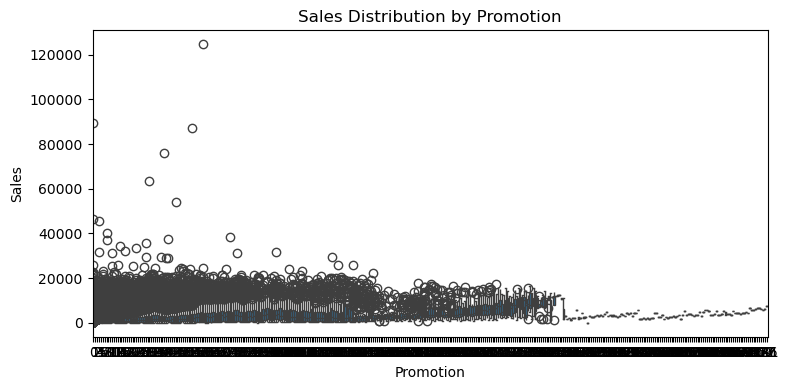

In [28]:
# 프로모션 유무에 따른 판매량 분포 시각화
plt.figure(figsize=(8, 4))
sns.boxplot(x="onpromotion", y="sales", data=train)
plt.title("Sales Distribution by Promotion")
plt.xlabel("Promotion")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

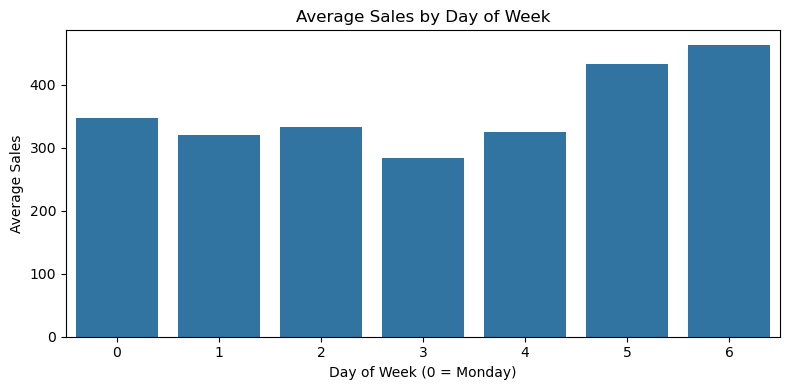

In [29]:
# 요일별 판매량 평균 산출
train["weekday"] = train["date"].dt.dayofweek
weekday_sales = train.groupby("weekday")["sales"].mean()

# 요일별 평균 판매량 시각화
plt.figure(figsize=(8, 4))
sns.barplot(x=weekday_sales.index, y=weekday_sales.values)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week (0 = Monday)")
plt.ylabel("Average Sales")
plt.tight_layout()
plt.show()


---

# step3: 시계열 예측

In [ ]:
import pandas as pd

# 데이터 재로드
train = pd.read_csv("train.csv", parse_dates=["date"])
test = pd.read_csv("test.csv", parse_dates=["date"])

# store_nbr, family 단위로 일자별 판매량 집계
grouped_sales = train.groupby(["store_nbr", "family", "date"])["sales"].sum().reset_index()

# 예시: 특정 store_nbr=1, family="GROCERY I" 선택
sample_store = 1
sample_family = "GROCERY I"

sample_df = grouped_sales[
    (grouped_sales["store_nbr"] == sample_store) &
    (grouped_sales["family"] == sample_family)
].sort_values("date").reset_index(drop=True)

# 지연 변수 생성 (1~7일 전 판매량)
for lag in range(1, 8):
    sample_df[f"lag_{lag}"] = sample_df["sales"].shift(lag)

# 결측치 제거 (지연변수로 인해 생긴 앞부분 제거)
sample_df = sample_df.dropna().reset_index(drop=True)

sample_df.head(10)


,store_nbr,family,date,sales,lag_1,lag_2,lag_3,lag_4,lag_5,lag_6,lag_7
0,1,GROCERY I,2013-01-08,1782.0,2262.0,723.0,2216.0,2056.0,2121.0,2652.0,0.0
1,1,GROCERY I,2013-01-09,2429.0,1782.0,2262.0,723.0,2216.0,2056.0,2121.0,2652.0
2,1,GROCERY I,2013-01-10,1544.0,2429.0,1782.0,2262.0,723.0,2216.0,2056.0,2121.0
3,1,GROCERY I,2013-01-11,1750.0,1544.0,2429.0,1782.0,2262.0,723.0,2216.0,2056.0
4,1,GROCERY I,2013-01-12,1796.0,1750.0,1544.0,2429.0,1782.0,2262.0,723.0,2216.0
5,1,GROCERY I,2013-01-13,961.0,1796.0,1750.0,1544.0,2429.0,1782.0,2262.0,723.0
6,1,GROCERY I,2013-01-14,1902.0,961.0,1796.0,1750.0,1544.0,2429.0,1782.0,2262.0
7,1,GROCERY I,2013-01-15,1671.0,1902.0,961.0,1796.0,1750.0,1544.0,2429.0,1782.0
8,1,GROCERY I,2013-01-16,2387.0,1671.0,1902.0,961.0,1796.0,1750.0,1544.0,2429.0
9,1,GROCERY I,2013-01-17,1648.0,2387.0,1671.0,1902.0,961.0,1796.0,1750.0,1544.0


### 적용 사례

- 매장: `store_nbr = 1`
- 상품군: `family = "GROCERY I"`
- 목적: 이 조합에 대해 일별 판매량 예측 모델을 설계하기 위한 입력 데이터 생성

### 처리 절차

1. `store_nbr`, `family`, `date` 기준으로 **일별 판매량 집계**
2. 최근 7일간의 판매량을 지연변수(`lag_1` ~ `lag_7`)로 생성
3. 결측치 제거 (시작 부분 7일간은 삭제)

In [32]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
import numpy as np

# 입력 변수(X)와 타깃 변수(y) 분리
feature_cols = [f"lag_{i}" for i in range(1, 8)]
X = sample_df[feature_cols]
y = sample_df["sales"]

# 훈련/검증 데이터 분할 (80% 학습, 20% 테스트)
split_idx = int(len(X) * 0.8)
X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
y_train, y_test = y.iloc[:split_idx], y.iloc[split_idx:]

# 선형 회귀 모델 학습
model = LinearRegression()
model.fit(X_train, y_train)

# 예측 수행
y_pred = model.predict(X_test)

# RMSLE 계산
rmsle = np.sqrt(np.mean((np.log1p(y_test) - np.log1p(y_pred)) ** 2))
rmsle


0.5326880412142294

### **선형 회귀 예측 결과**

- 사용 모델: `LinearRegression`
- 입력 변수: 최근 7일간 판매량 (`lag_1` ~ `lag_7`)
- 평가 지표: **RMSLE (Root Mean Squared Logarithmic Error)**

### 예측 성능 결과

- **RMSLE**: `0.533`

---

# step4: auto_arima 기반 예측 모델 도입

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller
import pmdarima as pm

# 데이터 재로드 및 전처리
train = pd.read_csv("train.csv", parse_dates=["date"])
grouped_sales = train.groupby(["store_nbr", "family", "date"])["sales"].sum().reset_index()

# 예시: 특정 매장/상품군 선택
sample_store = 1
sample_family = "GROCERY I"
sample_df = grouped_sales[
    (grouped_sales["store_nbr"] == sample_store) &
    (grouped_sales["family"] == sample_family)
].sort_values("date").reset_index(drop=True)


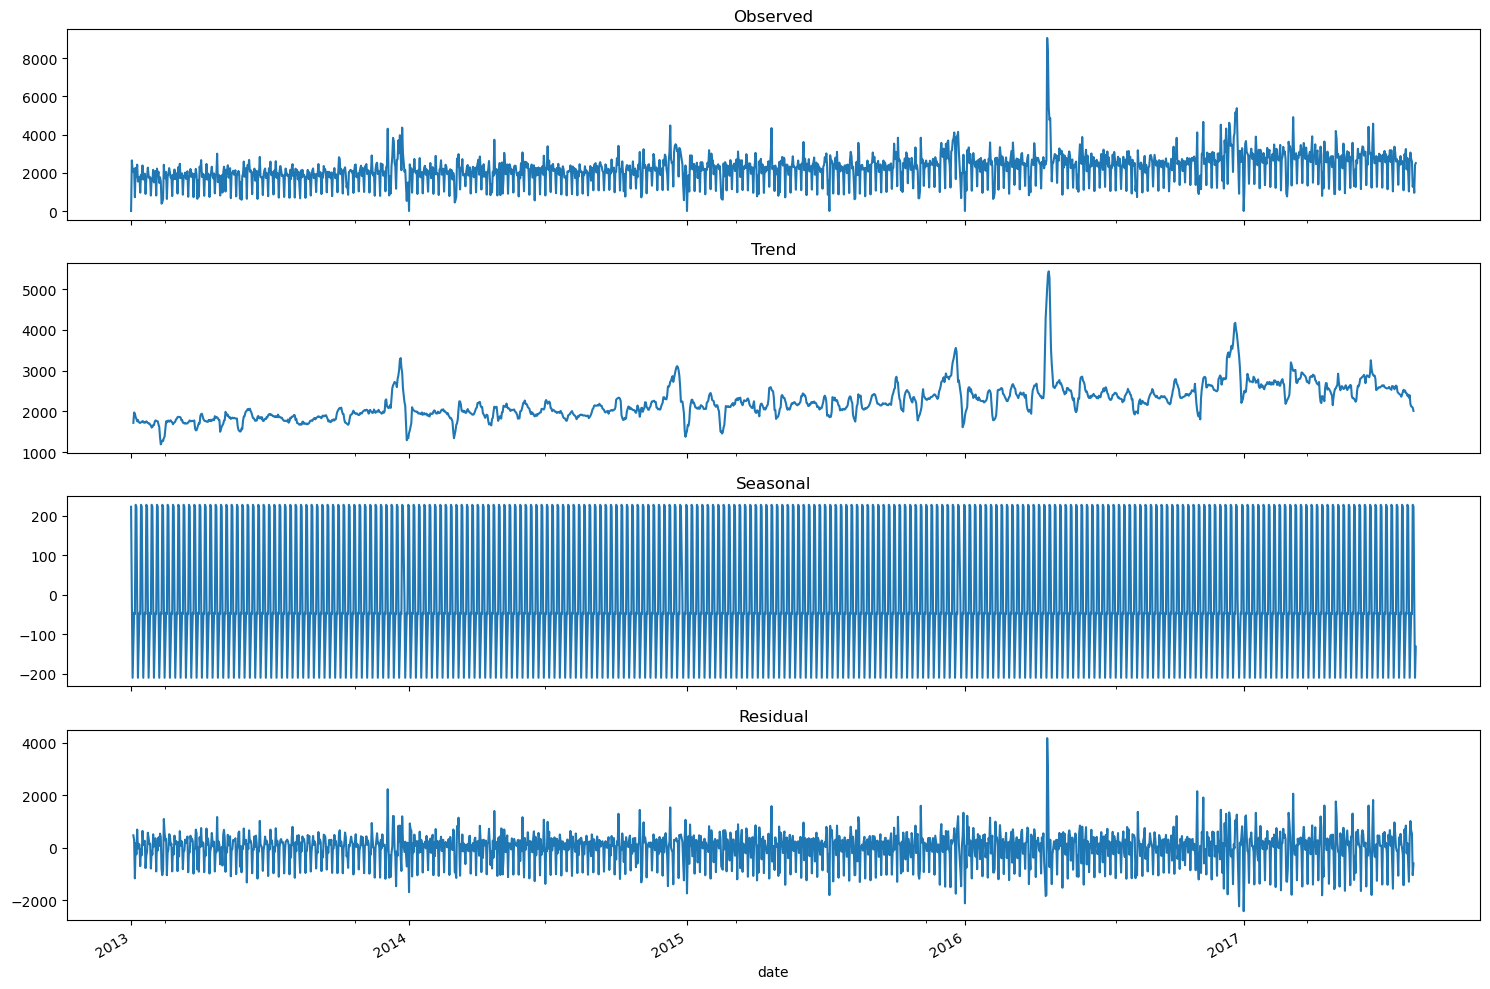

In [3]:
# 시계열 형태로 변환 (date를 인덱스로 설정)
ts = sample_df.set_index("date")["sales"]

# 시계열 분해 (추세, 계절성, 잔차)
decomposition = seasonal_decompose(ts, model='additive', period=7)

# 시각화
fig, axes = plt.subplots(4, 1, figsize=(15, 10), sharex=True)
decomposition.observed.plot(ax=axes[0], title='Observed')
decomposition.trend.plot(ax=axes[1], title='Trend')
decomposition.seasonal.plot(ax=axes[2], title='Seasonal')
decomposition.resid.plot(ax=axes[3], title='Residual')
plt.tight_layout()
plt.show()

In [14]:
import pmdarima as pm

# 시계열 데이터 생성 (index: date, values: sales)
ts = sample_df.set_index("date")["sales"]
ts_clean = ts.dropna()
ts_clean = ts_clean.astype(float)  # float 강제 형변환

In [16]:
ts.isna().sum()

0

In [17]:
from statsmodels.tsa.stattools import adfuller

adfuller_result = adfuller(ts_clean)

print("ADF Statistic:", adfuller_result[0])
print("p-value:", adfuller_result[1])


ADF Statistic: -4.150401045659749
p-value: 0.0007985311957746438


In [18]:
ts_diff = ts_clean.diff().dropna()


### 목적

- `store_nbr = 1`, `family = "GROCERY I"`에 대한 시계열 데이터를 기반으로
- `auto_arima`를 활용하여 예측 모델을 자동 설정하고
- 향후 15일간의 판매량 예측


In [21]:
model = pm.auto_arima(
    ts_clean,
    seasonal=True,
    m=7,  # 일간 데이터 → 주간 계절성
    start_p=1, start_q=1,
    max_p=2, max_q=2,
    start_P=0, seasonal_test='ocsb',
    d=None, D=1,  # 명시적으로 계절 차분 설정
    stepwise=True,
    trace=True,
    error_action='ignore',
    suppress_warnings=True,
    max_order=5,  # 전체 차수 제한
    n_fits=10     # 모델 탐색 개수 제한
)
forecast = model.predict(n_periods=15)

# 요약 정보 출력
print(model.summary())

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=25684.162, Time=1.12 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=26796.688, Time=0.04 sec


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=25990.555, Time=0.46 sec


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


...

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(1,1,0)[7]             : AIC=25939.045, Time=0.87 sec


/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


 ARIMA(2,0,2)(1,1,2)[7]             : AIC=inf, Time=4.13 sec

Best model:  ARIMA(2,0,2)(0,1,1)[7]          
Total fit time: 42.137 seconds
                                      SARIMAX Results                                      
Dep. Variable:                                   y   No. Observations:                 1684
Model:             SARIMAX(2, 0, 2)x(0, 1, [1], 7)   Log Likelihood              -12833.738
Date:                             Tue, 27 May 2025   AIC                          25679.475
Time:                                     02:23:21   BIC                          25712.024
Sample:                                          0   HQIC                         25691.533
                                            - 1684                                         
Covariance Type:                               opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


## 1. 모델 구성 요약

- **ARIMA(2,0,2)**: 비계절 성분
    - **p=2**: 자기회귀(AR) 항이 2차까지 포함됨
    - **d=0**: 차분을 수행하지 않음 → 정상 시계열로 간주됨
    - **q=2**: 이동평균(MA) 항도 2차 포함
- **(0,1,1)[7]**: 계절 성분 (주기 7일 기준)
    - **P=0**: 계절 자기회귀 미포함
    - **D=1**: **계절 차분 1회 수행됨** → 주기성 제거 효과
    - **Q=1**: 계절 이동평균 항 포함
    - **[7]**: 주기가 7일, 즉 **주간 패턴 존재**

---

## 2. 주요 계수 해석

| 계수 | 계수값 | 해석 |
| --- | --- | --- |
| `ar.L1 = 1.6029`, `ar.L2 = -0.6133` | 시차 1~2일 전 판매량이 강한 영향을 줌 (자기회귀 효과) |  |
| `ma.L1 = -1.2528`, `ma.L2 = 0.2604` | 시차 1~2일 전의 예측 오차가 반영됨 (최근 예측이 과소했는가?) |  |
| `ma.S.L7 = -0.7590` | **7일 전 예측 오차에 강한 영향** → 뚜렷한 주간 패턴 존재 |  |
| `sigma2 ≈ 258,900` | 잔차 분산이 큼 → 데이터의 노이즈가 상당함 (계절성+프로모션 등 영향 때문일 수 있음) |  |

모든 계수의 **p-value < 0.05** → **모든 계수 통계적으로 유의함**

---

## 3. 진단 통계 지표

| 지표 | 결과 | 해석 |
| --- | --- | --- |
| **AIC = 25679.5** | 모델 비교를 위한 기준 지표로, 낮을수록 좋음 |  |
| **Ljung-Box Q (L1) = 0.01, Prob = 0.92** | 잔차가 **백색잡음에 가까움** → 모델이 잘 적합됨 |  |
| **Jarque-Bera = 20456.8, Prob = 0.00** | 잔차가 정규분포는 아님 → 노이즈 분포는 왜도·첨도 있음 |  |

---

## 4. 종합 해석 및 시사점

### 이 모델은 적절한가?

- 시계열 분해에서 **주간 계절성**이 있었고, `m=7`이 잘 반영됨
- 모든 계수가 통계적으로 유의하고, 잔차도 백색잡음 형태
- `d=0`인 점은 시계열이 본질적으로 정상적임을 시사
- 잔차 정규성이 떨어지는 점은 노이즈의 비정상성(특정 이벤트 영향 등)을 반영

### 어떤 시나리오에 적합한 모델인가?

- 예측 대상이 **정기적이고 반복적인 수요**를 가지며
- 단기(15일 내외) 예측을 수행하는 경우 매우 적합
- 프로모션, 공휴일 등 외부 변수는 반영하지 않았기 때문에 **실전 배포 시 exog 변수를 추가하는 것이 권장**

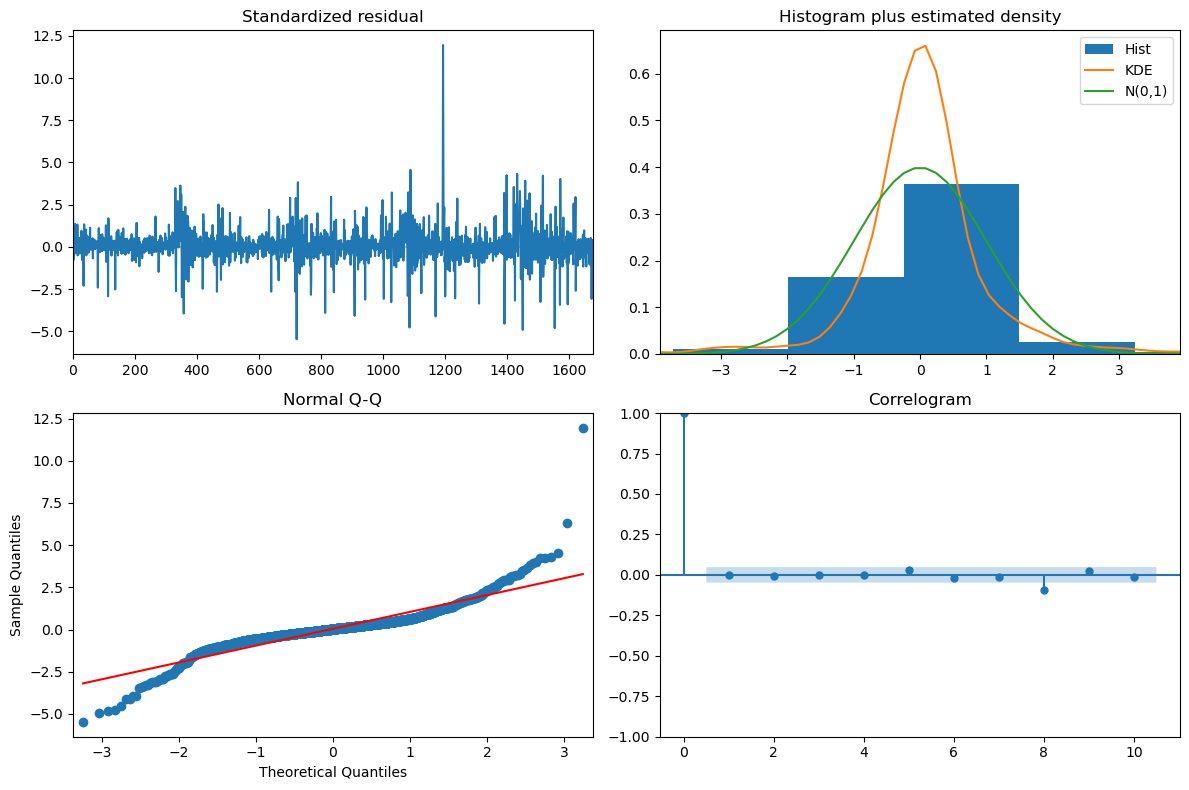

/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/statsmodels/tsa/base/tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(
/Users/khb43/anaconda3/envs/HUFS_AI_Study/lib/python3.10/site-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


,date,predicted_sales
1684,2017-08-16,2908.754920
1685,2017-08-17,2469.476202
1686,2017-08-18,2454.409154
1687,2017-08-19,2312.862864
1688,2017-08-20,1169.742174
1689,2017-08-21,2757.130579
1690,2017-08-22,2920.366720
1691,2017-08-23,3110.235301
1692,2017-08-24,2599.232304
1693,2017-08-25,2538.822850


In [22]:
# 진단 시각화
model.plot_diagnostics(figsize=(12, 8))
plt.tight_layout()
plt.show()

# 15일 후 예측
n_periods = 15
forecast = model.predict(n_periods=n_periods)

# 예측 결과를 DataFrame으로 변환
future_dates = pd.date_range(start=ts.index.max() + pd.Timedelta(days=1), periods=n_periods)
forecast_df = pd.DataFrame({"date": future_dates, "predicted_sales": forecast})

forecast_df.head(10)